<a href="https://colab.research.google.com/github/Yahir-7/GeoPandas/blob/main/Extreme_Heat_2020.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

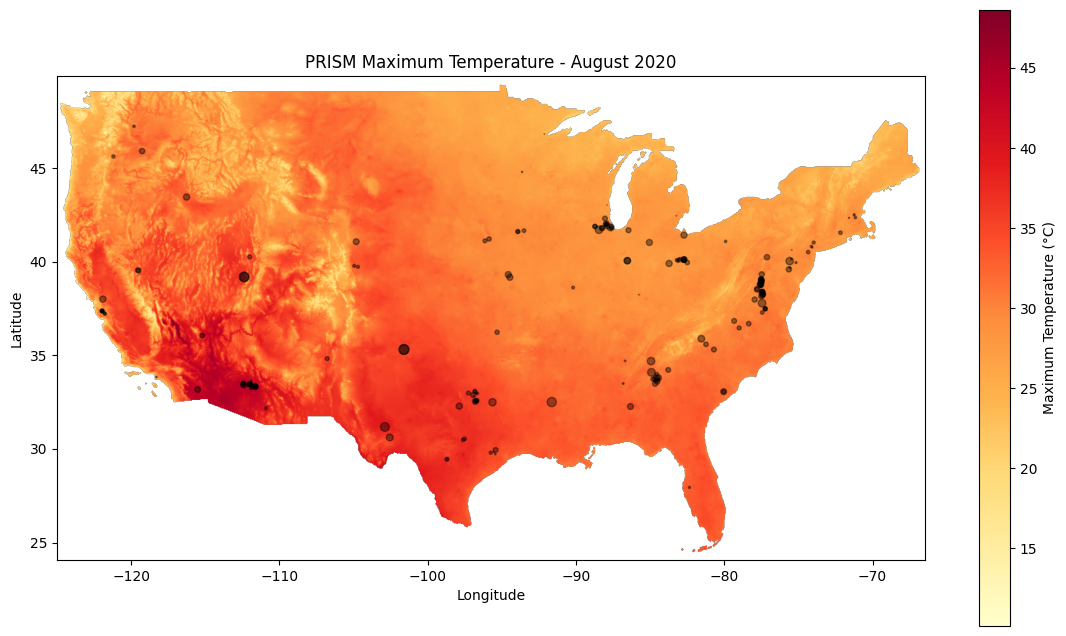

In [7]:
# Run once
# !pip install rasterio geopandas numpy pandas matplotlib

import geopandas
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from rasterio.plot import show

dc = pd.read_excel("/content/Aterio US Data Centers Dashboard.xlsx", sheet_name = "Data Sample")
dc = dc[[
        "DATA_CENTER_BUILDING_NAME",
        "PROVIDER_NAME",
        "DATA_CENTER_STAGE",
        "FULL_ADDRESS",
        "CITY_NAME",
        "STATE_NAME",
        "LOCATION_LATITUDE",
        "LOCATION_LONGITUDE",
        "SELECTED_POWER_CAPACITY_MW",
        "DATA_CENTER_ACTIVATION_DATE",
        "DATA_CENTER_ANNOUNCED_DATE",
        "RECORD_UPDATED_DATE"
    ]
  ]
dc = dc.dropna(subset=["LOCATION_LATITUDE", "LOCATION_LONGITUDE"])
data_centers = geopandas.GeoDataFrame(
    dc, geometry=geopandas.points_from_xy(dc.LOCATION_LONGITUDE, dc.LOCATION_LATITUDE),
    crs= "EPSG:4326"
)
with rasterio.open("/content/prism_tmax_us_25m_202008.tif") as dataset:
  temp = dataset.read(1)
  temp = np.where(temp == -9999, np.nan, temp)
  fig, ax = plt.subplots(figsize = (14, 8))
  img = ax.imshow(
        temp,
        extent=[dataset.bounds.left, dataset.bounds.right,
            dataset.bounds.bottom, dataset.bounds.top
        ] ,
        cmap="YlOrRd"
    )
  plt.colorbar(img, ax=ax, label="Maximum Temperature (°C)")
  plt.title("PRISM Maximum Temperature - August 2020")
  plt.xlabel("Longitude")
  plt.ylabel("Latitude")
  data_centers.plot (
      ax = ax, markersize = dc["SELECTED_POWER_CAPACITY_MW"]/ 5,
      alpha = 0.4,
      color = "black",
      legend = True,
      legend_kwds = {"label" : "Data Center Locations"}
 )
  plt.show()
